In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
from scipy.integrate import odeint
import h5py
import math

from mpl_toolkits.mplot3d import axes3d
%matplotlib widget

In [2]:
Nc=4
Nf=1

In [3]:
Ns=32
Nt=8

In [4]:
gstar_HSDM = 2*(Nc**2-1)+2*Nf**2
gstar_SM = 106.75
gstar = gstar_SM + gstar_HSDM
Om_HSDM = gstar_HSDM / (gstar_HSDM+gstar_SM)

In [5]:
MP_GeV = 1.220890 * 10**19 # GeV https://physics.nist.gov/cgi-bin/cuu/Value?plkmc2gev

In [6]:
two_param = False

In [7]:
eps=1.0

In [8]:
class Jackknife:
    def __init__( self, len_data, binsize ):
        self.binsize = binsize
        self.nbins = math.floor( len_data/self.binsize )
        self.N = self.binsize * self.nbins
        self.jack_avg = []
        self.est = 0
        self.var_est = 0

    def set( self, func, list_of_data ):
        for i in range( self.nbins ):
            self.jack_avg.append( func( i, self.binsize, list_of_data ) )

    def do_it( self ):
        for i in range( 0, self.nbins ):
            self.est += self.jack_avg[i]
        self.est /= self.nbins

        for i in range( 0, self.nbins ):
            self.var_est += ( self.jack_avg[i] - self.est )**2
        self.var_est /= self.nbins
        self.var_est *= self.nbins -1

    def mean( self ):
        return self.est

    def var( self ):
        return self.var_est

    def err( self ):
        return np.sqrt(self.var_est)

def simple_mean(i, binsize, np_data):
    resmpld = np.delete(np_data, np.s_[i*binsize:(i+1)*binsize], axis=0)
    return np.mean(resmpld, axis=0)

def jk_avg(i, binsize, np_data):
    return np_data[i]

def format_print(cen, err):
    for i in range(-50, 50):
        if 10**(-i+1)>=err>10**(-i):
            tmp=err*10**(i+1)
            return '{num:.{width}f}'.format(num=cen, width=i+1)+'('+str(round(tmp))+')'

def format_print_w_exact(exact, cen, err):
    for i in range(-50, 50):
        if 10**(-i+1)>=err>10**(-i):
            tmp=err*10**(i+1)
            return '{num:.{width}f}'.format(num=cen, width=i+1)+'('+str(round(tmp))+')'+': '+'{num:.{width}f}'.format(num=(exact-cen)/err, width=i+1)+' sigma'

class Jackknife2:
    def __init__( self, len_data, binsize ):
        self.binsize = binsize
        self.nbins = math.floor( len_data/self.binsize )
        self.N = self.binsize * self.nbins
        self.jack_avg = []
        self.est = 0
        self.cov_est = 0

    def set( self, func, list_of_data ):
        for i in range( self.nbins ):
            self.jack_avg.append( func( i, self.binsize, list_of_data ) )

    def do_it( self ):
        for i in range( 0, self.nbins ):
            self.est += self.jack_avg[i]
        self.est /= self.nbins

        for i in range( 0, self.nbins ):
            self.cov_est += np.kron( self.jack_avg[i] - self.est, self.jack_avg[i] - self.est )
        self.cov_est /= self.nbins
        self.cov_est *= self.nbins -1
        self.cov_est = self.cov_est.reshape( self.est.shape[0], self.est.shape[0] )

    def mean( self ):
        return self.est

    def cov( self ):
        return self.cov_est

    def err( self ):
        return np.sqrt(self.cov_est.diagonal())

# GW

In [9]:
class F_Gammahat:
    def __init__( self, f_S3 ):
        self.f_S3 = f_S3

    def __call__( self, TmTc, MB ):
        S3 = self.f_S3( TmTc, MB )
        coeff = (S3/(2.0*np.pi))**(3.0/2.0)
        efactor = np.exp( -S3 )
        return coeff * efactor

    # def dT( self, TmTc, MB ):
    #     S3 = self.f_S3( TmTc, MB )
    #     DS3 = self.f_S3.dT( TmTc, MB )
    #     coeff = (3.0/(4.0*np.pi)) * (S3/(2.0*np.pi))**(1.0/2.0) * np.exp( -S3 )
    #     coeff -= (S3/(2.0*np.pi))**(3.0/2.0) * np.exp( -S3 )
    #     return np.abs(coeff) * DS3

    def dT( self, TmTc, MB ):
        S3 = self.f_S3( TmTc, MB )
        DS3 = self.f_S3.dT( TmTc, MB )
        coeff = (S3/(2.0*np.pi))**(3.0/2.0)
        dcoeff = 1.5*(S3/(2.0*np.pi))**(1.0/2.0)/(2.0*np.pi)
        
        efactor = np.exp( -S3 )
        defactor = -np.exp( -S3 )

        return (dcoeff * efactor + coeff * defactor)*DS3

In [10]:
def get_gw_params( f_Tc, f_DV, f_S3 ):
    Tc = f_Tc(MB)
    Ts = np.linspace(Tc-DTc, Tc, NTs, endpoint=False)
    dT = Ts[1]-Ts[0]

    f_Gammahat = F_Gammahat( f_S3 )
    GamPrimes = f_Gammahat( Ts-Tc, MB )
    DGamPrimes = [f_Gammahat.dT( tmtc, MB ) for tmtc in Ts-Tc]

    alpha = (1.0/3.0)
    
    for it in range(2):
        vJ = ( np.sqrt(2.0*alpha/3.0 + alpha**2) + np.sqrt(1.0/3.0) ) / (1.0+alpha)
    
        # Hsqs = Ts**4/(3.0*MP**2) * ( np.pi**2/30.0 * gstar + DVPrimes*Ps_tmp )
        Hsqs = Ts**4/(3.0*MP**2) * ( np.pi**2/30.0 * gstar )
        Hinv = Hsqs**(-0.5)
        
        T2TpDTInt_=[]
        for iT in np.arange(0,NTs):
            tmp = []
            for iDT in np.arange(0,NTs-iT):
                integrand = dT * Hinv[iT:iT+iDT] * vJ
                tmp.append( np.sum(integrand) )
            T2TpDTInt_.append(tmp)
        T2TpDTInt = T2TpDTInt_
        
        Is_ = []
        for iT in np.arange(0,NTs):
            integral = 0.0
            for iDT in np.arange(0,NTs-iT):
                Tprime = iT+iDT
                integral += dT*Hinv[Tprime] * GamPrimes[Tprime] * T2TpDTInt[iT][iDT]**3
            Is_.append(integral * 4.0*np.pi/3.0 )
        Is = np.nan_to_num(np.array(Is_), nan=1.e10)
        
        iTstar = np.argmin( (Is-0.34)**2 )
        Tstar = Ts[iTstar]
        
        DVPrime = f_DV( Tstar-Tc, MB )
        dDVPrime_dT = f_DV.dT( Tstar-Tc, MB )
        
        numer = Tstar*dDVPrime_dT
        denom = Tstar*dDVPrime_dT + 4.0*DVPrime
        
        alpha = (1.0/3.0) * numer/denom
        
        # print( alpha )
    vJ = ( np.sqrt(2.0*alpha/3.0 + alpha**2) + np.sqrt(1.0/3.0) ) / (1.0+alpha)
    beta_tilde = Tstar * f_S3.dT( Tstar-Tc, MB )

    return alpha, vJ, beta_tilde, Tstar, Tc

In [11]:
def get_freq_amplitude( args ):
    alpha, vJ, beta_tilde, Tstar, Tc = args
    kappa_v = np.sqrt(alpha)/(0.135+np.sqrt(0.98+alpha))
    Ubarfsq = 3.0/4.0 * alpha/(1.0+alpha) * kappa_v
    tau_sw = 1 - 1.0 / np.sqrt( 1.0 + 2.0*(8.0*np.pi)**(1.0/3.0) * vJ / ( beta_tilde*np.sqrt(Ubarfsq) ) )
    kappa_sw = np.sqrt(tau_sw)*kappa_v
    
    fpeak = 1.9*1.0e-5 * (gstar/100.)**(1.0/6.0) * (Tstar*sqrt_t0_inv_GeV/100.) * (beta_tilde / vJ)
    hsq_Omega_peak = 2.65*1.0e-6 * (vJ/beta_tilde) * (kappa_sw*alpha/(1.0+alpha))**2 * (100./gstar)**(1.0/3.0) * Om_HSDM**2
    
    return fpeak, hsq_Omega_peak

In [12]:
NTs = 100
# NTs = 400
DTc = 0.0004 # from DVPrime

In [16]:
nbetas = {
    '0p2000':9,
    '0p3000':8,
    '0p4000':8
}
nbins=40

In [17]:
class F_Tc:
    def fitter( self, MB, b0, b1 ):
        return b0+b1*MB

    def __init__( self, fp ):
        self.fp = fp

    def __call__( self, MB ):
        return self.fitter( MB, self.fp[0], self.fp[1] )

In [18]:
if two_param:
    class F_DeltaV:
        def fitter(self, TmTc_MB, a0, b0):
            TmTc = TmTc_MB[0]
            MB = TmTc_MB[1]
            return TmTc * ( a0 + b0*MB )
        
        def __init__( self, fp ):
            self.fp = fp
    
        def __call__( self, TmTc, MB ):
            return self.fitter( [TmTc, MB], self.fp[0], self.fp[1] )
    
        def dT( self, TmTc, MB ):
            a0 = self.fp[0]
            b0 = self.fp[1]
            return ( a0 + b0*MB )

else:
    class F_DeltaV:
        def fitter(self, TmTc_MB, a0, b0, c0, d0):
            TmTc = TmTc_MB[0]
            MB = TmTc_MB[1]
            return TmTc * ( a0 + b0*MB ) + TmTc**2 * ( c0 + d0*MB )
        
        def __init__( self, fp ):
            self.fp = fp
    
        def __call__( self, TmTc, MB ):
            return self.fitter( [TmTc, MB], self.fp[0], self.fp[1], self.fp[2], self.fp[3] )
    
        def dT( self, TmTc, MB ):
            a0 = self.fp[0]
            b0 = self.fp[1]
            c0 = self.fp[2]
            d0 = self.fp[3]
            return ( a0 + b0*MB ) + 2.0*TmTc * ( c0 + d0*MB )

In [19]:
class F_S3hat:
    def fitter(self, TmTc_MB, Mc, c0, c1, c2, gam ):
        TmTc = TmTc_MB[0]
        MB = TmTc_MB[1]
        return (MB-Mc)**gam  * ( c0 + c1/TmTc + c2/TmTc**2 )

    def __init__( self, fp ):
        self.fp = fp

    def __call__( self, TmTc, MB ):
        return self.fitter( [TmTc, MB], self.fp[0], self.fp[1], self.fp[2], self.fp[3], self.fp[4] )

    def dT( self, TmTc, MB ):
        Mc = self.fp[0]
        c0 = self.fp[1]
        c1 = self.fp[2]
        c2 = self.fp[3]
        gam = self.fp[4]
        return (MB-Mc)**gam  * ( -1.0*c1/TmTc**2 -2.0 * c2/TmTc**3 )

In [20]:
f = h5py.File('Tcparams.hdf5', 'r')
Tcparams=f['mean'][:]
jk_Tcparams_m0p2000=f['jk_m0p2000'][:]
jk_Tcparams_m0p3000=f['jk_m0p3000'][:]
jk_Tcparams_m0p4000=f['jk_m0p4000'][:]
f.close()

In [21]:
jk_Tcparams_m0p2000.shape

(9, 40, 2)

In [22]:
f = h5py.File('DeltaVparams.hdf5', 'r')
DeltaVparams=f['mean'][:]
jk_DeltaVparams_m0p2000=f['jk_m0p2000'][:]
jk_DeltaVparams_m0p3000=f['jk_m0p3000'][:]
jk_DeltaVparams_m0p4000=f['jk_m0p4000'][:]
f.close()

In [23]:
f = h5py.File('S3params.hdf5', 'r')
S3params=f['mean'][:]
jk_S3params_m0p2000=f['jk_m0p2000'][:]
jk_S3params_m0p3000=f['jk_m0p3000'][:]
jk_S3params_m0p4000=f['jk_m0p4000'][:]
f.close()

In [ ]:
results_=[]

for MBGeV in np.array([20.0, 50.0, 100.0, 200.0, 500.0]):
    for MB in np.array([2.6, 2.8, 3.0, 3.2, 3.4, 3.6, 3.8]):
        print(MBGeV, MB)

        sqrt_t0_inv_GeV = MBGeV/MB # GeV; free parameter
        MP = MP_GeV / sqrt_t0_inv_GeV

        # vary m=0.2
        jk_fO_m0p2000=[]
        mass="0p2000"
        
        for jdrop in np.arange(nbetas[mass]):
            jk_=[]
            for ibin in np.arange(nbins):
                # print(jdrop, ibin)
                f_Tc = F_Tc( jk_Tcparams_m0p2000[jdrop][ibin] )
                f_DV = F_DeltaV( jk_DeltaVparams_m0p2000[jdrop][ibin] )
                f_S3 = F_S3hat( jk_S3params_m0p2000[jdrop][ibin] )

                # print( f_Tc(3.2) )
                # print( f_DV(-0.000152, 3.2) )
                # print( f_S3(-0.000152, 3.2) )
        
                alpha, vJ, beta_tilde, Tstar, Tc = get_gw_params( f_Tc, f_DV, f_S3 )
                # print( alpha, vJ, beta_tilde, Tstar, Tc )
                assert Tstar-Tc > -0.00035
                meanparams = [alpha, vJ, beta_tilde, Tstar, Tc]
        
                f_m, om_m = get_freq_amplitude( meanparams )
                jk_.append( [f_m, om_m] )
            jk_fO_m0p2000.append( jk_ )
        
        
        # vary m=0.3
        jk_fO_m0p3000=[]
        mass="0p3000"
        
        for jdrop in np.arange(nbetas[mass]):
            jk_=[]
            for ibin in np.arange(nbins):
                # print(jdrop, ibin)
                f_Tc = F_Tc( jk_Tcparams_m0p3000[jdrop][ibin] )
                f_DV = F_DeltaV( jk_DeltaVparams_m0p3000[jdrop][ibin] )
                f_S3 = F_S3hat( jk_S3params_m0p3000[jdrop][ibin] )
        
                alpha, vJ, beta_tilde, Tstar, Tc = get_gw_params( f_Tc, f_DV, f_S3 )
                # print( alpha, vJ, beta_tilde, Tstar, Tc )
                assert Tstar-Tc > -0.00035
                meanparams = [alpha, vJ, beta_tilde, Tstar, Tc]
        
                f_m, om_m = get_freq_amplitude( meanparams )
                jk_.append( [f_m, om_m] )
            jk_fO_m0p3000.append( jk_ )
        
        
        # vary m=0.4
        jk_fO_m0p4000=[]
        mass="0p4000"
        
        for jdrop in np.arange(nbetas[mass]):
            jk_=[]
            for ibin in np.arange(nbins):
                # print(jdrop, ibin)
                f_Tc = F_Tc( jk_Tcparams_m0p4000[jdrop][ibin] )
                f_DV = F_DeltaV( jk_DeltaVparams_m0p4000[jdrop][ibin] )
                f_S3 = F_S3hat( jk_S3params_m0p4000[jdrop][ibin] )
        
                alpha, vJ, beta_tilde, Tstar, Tc = get_gw_params( f_Tc, f_DV, f_S3 )
                # print( alpha, vJ, beta_tilde, Tstar, Tc )
                # print(Tstar-Tc)
                assert Tstar-Tc > -0.00035
                meanparams = [alpha, vJ, beta_tilde, Tstar, Tc]
        
                f_m, om_m = get_freq_amplitude( meanparams )
                jk_.append( [f_m, om_m] )
            jk_fO_m0p4000.append( jk_ )

        var_tot = np.full( 2, 0. )

        # vary m=0.2
        mass="0p2000"
        for jdrop in np.arange(nbetas[mass]):
            jk_data = np.array( jk_fO_m0p2000[jdrop] )
            jk = Jackknife( nbins, 1 )
            jk.set( jk_avg, jk_data )
            jk.do_it()
            var_tot += jk.err()**2
        jk_data02=jk_data
        
        # vary m=0.3
        mass="0p3000"
        for jdrop in np.arange(nbetas[mass]):
            jk_data = np.array( jk_fO_m0p3000[jdrop] )
            jk = Jackknife( nbins, 1 )
            jk.set( jk_avg, jk_data )
            jk.do_it()
            var_tot += jk.err()**2
        jk_data03=jk_data
        
        # vary m=0.4
        mass="0p4000"
        for jdrop in np.arange(nbetas[mass]):
            jk_data = np.array( jk_fO_m0p4000[jdrop] )
            jk = Jackknife( nbins, 1 )
            jk.set( jk_avg, jk_data )
            jk.do_it()
            var_tot += jk.err()**2
        jk_data04=jk_data

        #######################MEAN

        f_Tc = F_Tc( Tcparams )
        f_DV = F_DeltaV( DeltaVparams )
        f_S3 = F_S3hat( S3params )

        alpha, vJ, beta_tilde, Tstar, Tc = get_gw_params( f_Tc, f_DV, f_S3 )
        # print( alpha, vJ, beta_tilde, Tstar, Tc )
        # print( Tstar-Tc )
        assert Tstar-Tc > -0.00035
        meanparams = [alpha, vJ, beta_tilde, Tstar, Tc]

        f_m, om_m = get_freq_amplitude( meanparams )

        print( "@@", [ MBGeV, MB, sqrt_t0_inv_GeV, [f_m, om_m], jk.mean(), np.sqrt( var_tot/eps**2 ), meanparams ] )
        results_.append( [ MBGeV, MB, sqrt_t0_inv_GeV, [f_m, om_m], jk.mean(), np.sqrt( var_tot/eps**2 ), meanparams ] )

20.0 2.6
@@ [20.0, 2.6, 7.692307692307692, [0.33283345513565404, 8.573012140622374e-21], array([2.99474091e-01, 1.11748404e-20]), array([7.01465425e-01, 5.29655776e-20]), [0.3336362603782142, 0.866090954665046, 1190265.3669746958, 0.15690288600630406, 0.15693888600630407]]
20.0 2.8
@@ [20.0, 2.8, 7.142857142857143, [0.15927822042568554, 3.345762170722094e-20], array([1.55282697e-01, 3.54601170e-20]), array([1.32033011e-01, 6.47658982e-20]), [0.33393202894661606, 0.8661548895341241, 603004.5992389201, 0.15962476380064672, 0.1596967638006467]]
20.0 3.0
@@ [20.0, 3.0, 6.666666666666667, [0.09758751231187235, 8.044213672707777e-20], array([1.00477624e-01, 7.63306140e-20]), array([8.12560086e-02, 1.17859181e-19]), [0.3342621666462149, 0.8662261757923443, 389246.845257922, 0.16234264159498935, 0.16245464159498935]]
20.0 3.2
@@ [20.0, 3.2, 6.25, [0.07739514247952285, 1.1638504792536598e-19], array([7.74496599e-02, 1.16278301e-19]), array([3.05819259e-02, 1.00556804e-19]), [0.334565332343247, 

In [46]:
jk_fO_m0p2000[0][1]

[0.33281113846897953, 8.574161955847876e-21]

In [25]:
Tstar-Tc

-0.00015200000000001324

In [26]:
MB

3.2

In [24]:
-3.600000000000825e-05 +0.00035

0.00031399999999999175

In [23]:
-3.600000000000825e-05 > -0.00035

True

In [84]:
jk.mean()

array([3.23086601e-01, 1.63413982e-19])

In [85]:
jk.mean(), np.sqrt( var_tot/eps**2 )

array([6.58958997e-02, 6.70308003e-20])

In [86]:
# err loop, eps factor

In [87]:
# central value

In [88]:
om_mean, f_mean = jk.mean()
om_err, f_err = jk.err()

In [89]:
dat = np.loadtxt("../peak-integrated_sensitivities/pis_s.dat")
LISA = np.loadtxt("../power-law-integrated_sensitivities/plis_LISA.dat")
BBO = np.loadtxt("../power-law-integrated_sensitivities/plis_BBO.dat")
DECIGO = np.loadtxt("../power-law-integrated_sensitivities/plis_DECIGO.dat")

HLVO2 = np.loadtxt("../power-law-integrated_sensitivities/plis_HLVO2.dat")

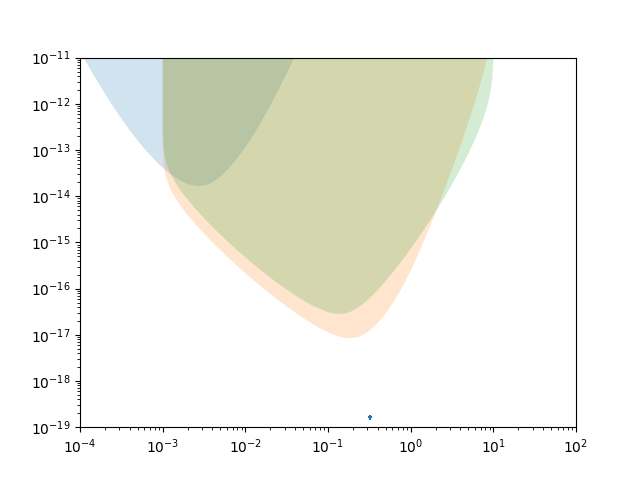

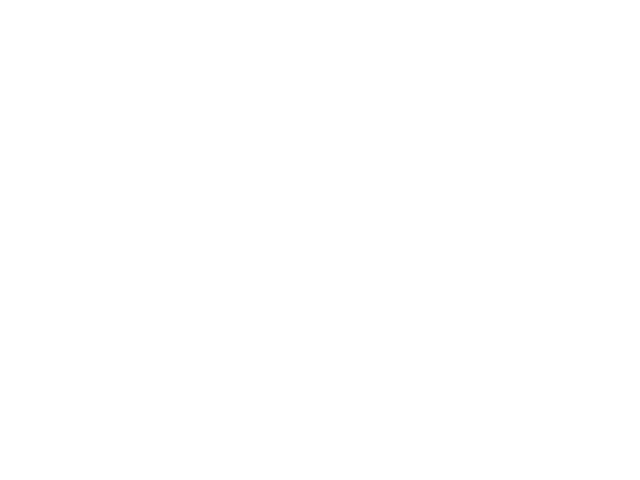

In [90]:
plt.clf()

fig = plt.figure()
ax = plt.axes()

# d=np.zeros(len(dat))+1.0

ax.fill_between( 10**LISA.T[0], 10**LISA.T[1], 1.0, label="LISA", alpha=0.2 )
ax.fill_between( 10**BBO.T[0], 10**BBO.T[1], 1.0, label="BBO", alpha=0.2 )
ax.fill_between( 10**DECIGO.T[0], 10**DECIGO.T[1], 1.0, label="DECIGO", alpha=0.2 )
# ax.fill_between( 10**HLVO2.T[0], 10**HLVO2.T[1], 1.0, label="HLVO2", alpha=0.2 )

#######################################

ax.errorbar( x=[om_mean], y=[f_mean], xerr=[om_err], yerr=[f_err] ) # , label="$M_B="+str(num)+"$GeV"
# for i, txt in enumerate(n):
#     txt2 = '{:.2f}'.format(txt)
#     ax.annotate(txt2, (x[i], y[i]))



plt.xscale("log")
plt.yscale("log")

plt.ylim(10**-19, 10**-11)
plt.xlim(10**-4, 100)


# plt.legend()

# plt.title("power-law-integrated sensitivity; annotation is $T_*$ in GeV")

# plt.savefig("sensitivity.pdf", bbox_inches='tight')
plt.show()